## Homework
Dataset:https://www.kaggle.com/datasets/shivamb/netflix-shows/data

In [3]:
import os
os.environ['KAGGLE_USERNAME'] = "Yuzefita"
os.environ['KAGGLE_KEY'] = "KGAT_2d0448415aa248b2fc32dcbb21e9bbcc"
!pip install kaggle
!kaggle datasets download -d shivamb/netflix-shows --force

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0




  0%|          | 0.00/1.34M [00:00<?, ?B/s]
 75%|#######4  | 1.00M/1.34M [00:00<00:00, 2.06MB/s]
100%|##########| 1.34M/1.34M [00:00<00:00, 2.49MB/s]


In [4]:
import zipfile
with zipfile.ZipFile("netflix-shows.zip", "r") as zip_ref:zip_ref.extractall("data

А) обзор данных

In [9]:
import pandas as pd
df = pd.read_csv('data/netflix_titles.csv')
print("Первые 5 строк")
display(df.head())
print("Размер таблицы")
print(df.shape)

df.info()

print("Статистика чисел")
display(df.describe())

print("Статистика тектса")
display(df.describe(include="object"))

Первые 5 строк


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Размер таблицы
(8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
Статистика чисел


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Статистика тектса


C:\Users\Acer\AppData\Local\Temp\ipykernel_12128\1991273127.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [10]:
print("ПОиск пропусков")
print(df.isnull().sum(). sort_values(ascending=False))
df_cleaned = df.copy()
df_cleaned['director'] = df_cleaned['director'].fillna('Unknown')
df_cleaned['cast'] = df_cleaned['cast'].fillna('Unknown')

country_mode = df_cleaned['country'].mode()[0]
df_cleaned['country'] = df_cleaned['country'].fillna(country_mode)
df_cleaned = df_cleaned.dropna(subset=['date_added', 'rating'])

print(df_cleaned.isnull().sum())
print(f"Shape: {df_cleaned.shape}")

ПОиск пропусков
director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64
Shape: (8793, 12)


Directors, cast заменила на unknowm т.к там будет невозможно  найти  среднее. date_added и rating  очень мало, поэтому просто можно удалить. Country можно заменить модой, т.к то, что фильм будет производста США большая вероятность 

С) расширенная статистика

In [13]:
from scipy.stats import skew, kurtosis
years = df_cleaned['release_year']
print(f"Min: {years.min()}")
print(f"Max: {years.max()}")
print(f"Mea): {years.mean():.2f}")
print(f"Median: {years.median()}")
print(f"Mode: {years.mode()[0]}")

percentiles = years.quantile([0.05, 0.25,0.5, 0.75, 0.95])
print("Перцентили:")
print(percentiles)
var_val = years.var()       
skew_val = years.skew()    
kurt_val = years.kurtosis() 

print(f"Variance: {var_val:.2f}")
print(f"Skewness: {skew_val:.2f}")
print(f"Kurtosis: {kurt_val:.2f}")

Min: 1925
Max: 2021
Mea): 2014.18
Median: 2017.0
Mode: 2018
Перцентили:
0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64
Variance: 77.87
Skewness: -3.45
Kurtosis: 16.22


Дисперсия показала что разброс по выходу фильмов довольно большой, значит есть как новые так и старые фильмы. ОТрицательная ассиметрия показала, что новых фильмов больше. Эксцесс покажет что график имееть острый пик, шде сосредоточено большое количество фильмов за последнюю десятку лет

In [15]:
data_example = df_cleaned[['title', 'type']].head(3)
data_encoded = pd.get_dummies(data_example, columns=['type'])
print("до")
print(data_example)
print("после")
print(data_encoded)

до
                  title     type
0  Dick Johnson Is Dead    Movie
1         Blood & Water  TV Show
2             Ganglands  TV Show
после
                  title  type_Movie  type_TV Show
0  Dick Johnson Is Dead        True         False
1         Blood & Water       False          True
2             Ganglands       False          True


Text(0, 0.5, 'количество')

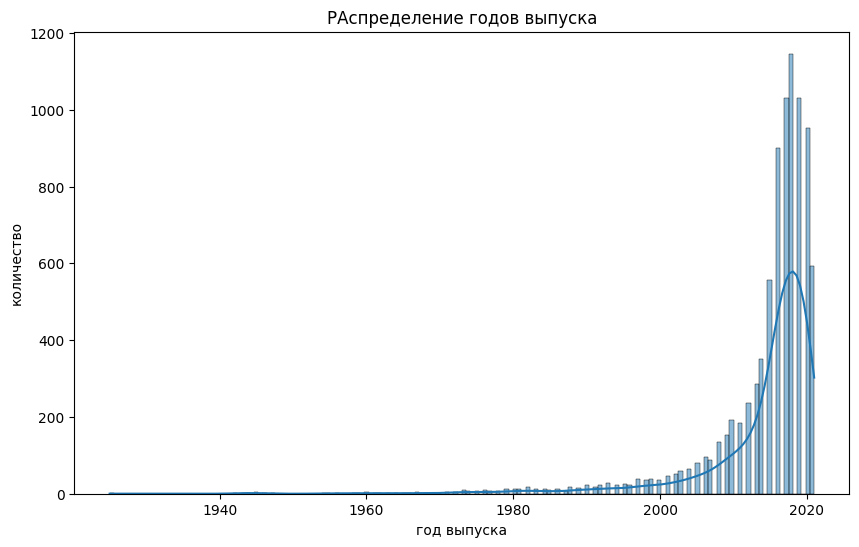

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['release_year'], kde=True)
plt.title('РАспределение годов выпуска')
plt.xlabel('год выпуска')
plt.ylabel('количество')

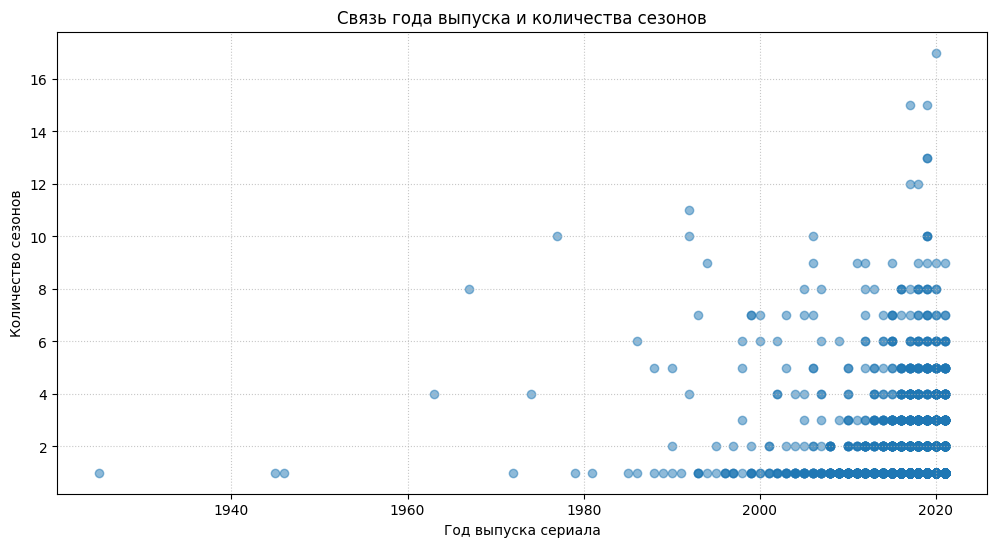

In [20]:
df_cleaned['seasons_count'] = df_cleaned['duration'].apply(
    lambda x: int(str(x).split()[0]) if 'Season' in str(x) else 0)
tv_shows = df_cleaned[df_cleaned['type'] == 'TV Show']

plt.figure(figsize=(12, 6))
plt.scatter(tv_shows['release_year'], tv_shows['seasons_count'],  alpha=0.5)
plt.title('Связь года выпуска и количества сезонов')
plt.xlabel('Год выпуска сериала')
plt.ylabel('Количество сезонов')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

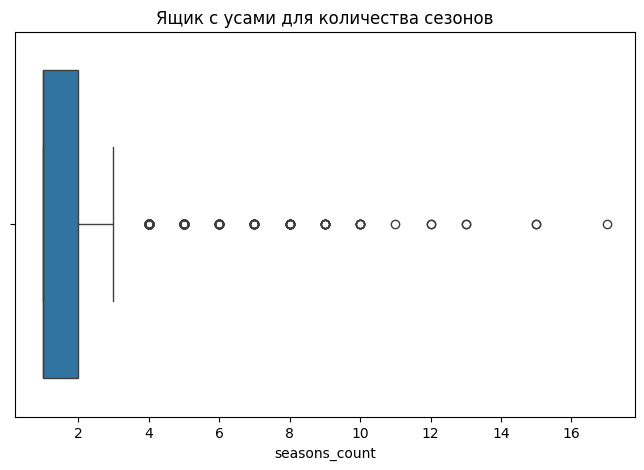

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_cleaned[df_cleaned['type'] == 'TV Show']['seasons_count'])
plt.title('Ящик с усами для количества сезонов')
plt.show()

In [25]:

import plotly.express as px

top_10_countries = df_cleaned['country'].value_counts().head(10).reset_index()

fig = px.bar(top_10_countries, x='country', y='count', 
             title='Топ-10 стран по количеству контента',
             labels={'count':'Количество', 'country':'Страна'},
             color='count', 
             hover_data=['country', 'count'])
fig.show()

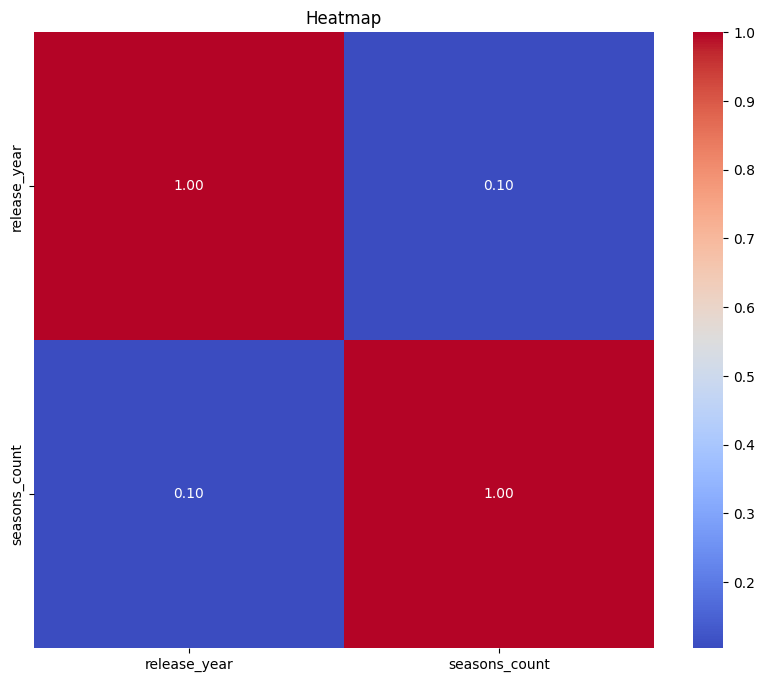

In [26]:
plt.figure(figsize=(10, 8))
numeric_df = df_cleaned.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap')
plt.show()

1. Новых фильмов и сериалов больше чем старых
2. Лидер по производству контента США
3. Сериалы часто длятся 2 сезона
4. Много пропусков режиссеров и каста